# K-Nearest Neighbors — Notebook Overview

This notebook fits a KNN classifier to predict coldwater indicator status (`cw_ind`) from geographic and watershed features, across multiple development-intensity thresholds.

---

## Cell Run Order

Cells 1 and 2 must be run first as all other cells rely on them. After that you can run the cells that are useful to you. NOTE that you no longer need to run the second cell for the third cell to work since the third cell has been hardcoded to K = 5, you can change this. 

---

## Cell Descriptions

| # | Description |
|---|-------------|
| **1** | **Data Loading & Subsets** — Reads `site_species_presence.csv`, selects the six modelling columns, and filters into five DataFrames (`all_3` … `all_15`) by `pct_dev` threshold. |
| **2** | **Hyperparameter Search (k)** — For each threshold dataset, runs a 5-fold stratified grid search over odd k values from 3–19 to find the best number of neighbors by ROC-AUC. Results are stored in `best_k`. |
| **3** | **Final Evaluation** — Trains a KNN model for each threshold using a 75/25 train/test split and prints a full classification report. Note: currently uses a fixed `k=5` rather than `best_k[name]` from Cell 2. |

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

all_years = pd.read_csv('./data/site_species_presence.csv')

all_years = all_years[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]


all_3 = all_years[all_years['pct_dev'] <= 3]
all_5 = all_years[all_years['pct_dev'] <= 5]
all_7 = all_years[all_years['pct_dev'] <= 7]
all_10 = all_years[all_years['pct_dev'] <= 10]
all_15 = all_years[all_years['pct_dev'] <= 15]

In [4]:
import sys
sys.path.append('./utils')
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

datasets = [
    ('pct_dev <= 3%',  all_3,  0.25),
    ('pct_dev <= 5%',  all_5,  0.25),
    ('pct_dev <= 7%',  all_7,  0.25),
    ('pct_dev <= 10%', all_10, 0.25),
    ('pct_dev <= 15%', all_15, 0.25),
]

best_k = {}

for name, df, _ in datasets:
    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        KNeighborsClassifier(),
        param_grid={'n_neighbors': range(3, 21, 2)},
        scoring='roc_auc',
        cv=cv,
    )
    grid.fit(X_scaled, y)
    best_k[name] = grid.best_params_['n_neighbors']
    print(f"{name}: best k={grid.best_params_['n_neighbors']}  (AUC={grid.best_score_:.4f})")


pct_dev <= 3%: best k=19  (AUC=0.7284)
pct_dev <= 5%: best k=19  (AUC=0.7982)
pct_dev <= 7%: best k=15  (AUC=0.7922)
pct_dev <= 10%: best k=9  (AUC=0.7884)
pct_dev <= 15%: best k=13  (AUC=0.8148)


Accuracy: 0.89
Precision: 0.91
Recall: 0.97
F1 Score: 0.94


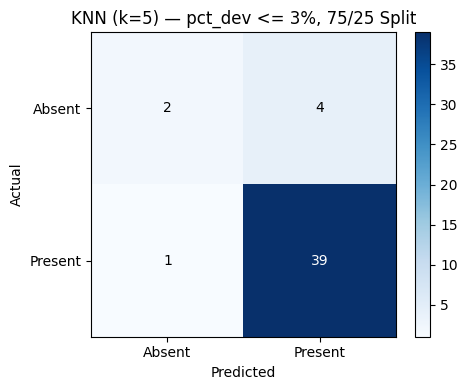

Accuracy: 0.81
Precision: 0.84
Recall: 0.92
F1 Score: 0.88


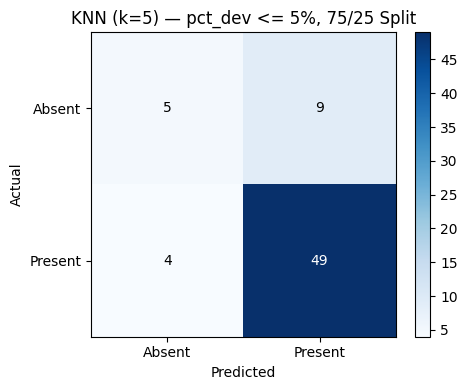

Accuracy: 0.74
Precision: 0.78
Recall: 0.92
F1 Score: 0.84


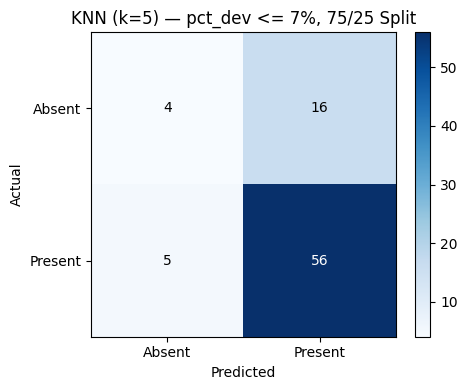

Accuracy: 0.78
Precision: 0.83
Recall: 0.88
F1 Score: 0.85


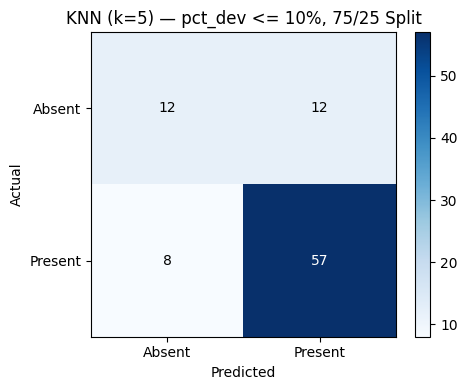

Accuracy: 0.80
Precision: 0.84
Recall: 0.90
F1 Score: 0.87


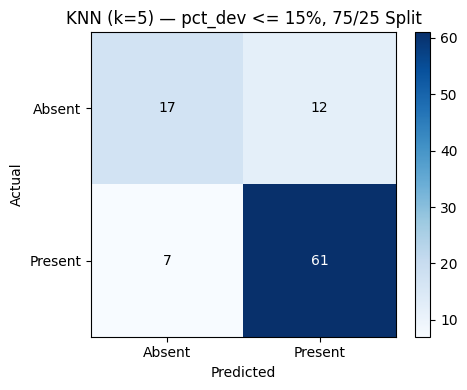

In [6]:
from utils.confusion import classification_report_suite

for name, df, test_size in datasets:
    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    k = best_k[name]
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    classification_report_suite(
        y_test, y_pred,
        labels=['Absent', 'Present'],
        title=f'KNN (k={5}) — {name}, {int((1-test_size)*100)}/{int(test_size*100)} Split'
    )
